In [1]:
%config InlineBackend.figure_formats = ['svg']
import quimb.tensor as qtn
import cotengra as ctg


import linalg_registrations
import dmrg_helpers
import boundary_states
import boundary_sweeps
import quf

In [2]:
linalg_registrations.reg_complex_svd()
import torch

to_backend = dmrg_helpers.backend_torch(device="cpu", dtype=torch.complex128, requires_grad=False)

# import jax
# import jax.numpy as jnp

# to_backend = dmrg_helpers.backend_jax(dtype=jnp.float64, device=jax.devices("cpu")[0])

opt = dmrg_helpers.opt_(progbar=True)

In [3]:
Lx, Ly = (4, 3)
p = qtn.PEPS.rand(Lx=Lx, Ly=Ly, bond_dim=2, seed=66, dtype="complex128")
p = qtn.PEPO.rand(Lx=Lx, Ly=Ly, bond_dim=3, seed=66, dtype="complex128")

p = boundary_states.add_diagonalu_tags(p)



pepo = qtn.PEPO.rand(Lx=Lx, Ly=Ly, bond_dim=2, seed=12, dtype="complex128")
pepo.add_tag('PEPO')
pepo = quf.add_diagonalu_tags(pepo)


re_inds = { indx:qtn.rand_uuid() for indx in p.inner_inds()}
ph = p.conj()
ph.reindex_( re_inds )

# pepsh.reindex_( {idx: qtn.rand_uuid() for idx in pepsh.inner_inds()} )

p.add_tag('KET')
ph.add_tag("BRA")

# ph.reindex_( { f"k{i},{j}":f"b{i},{j}" for i in range(Lx) for j in range(Ly)} )
#norm = ph | pepo | p

norm = ph | p

norm.apply_to_arrays(to_backend)


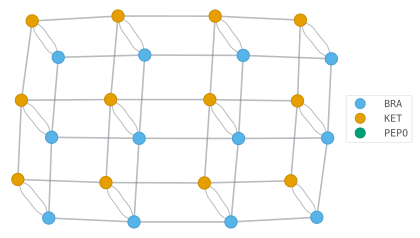

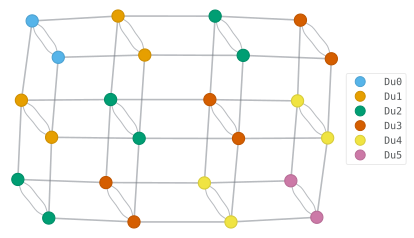

In [4]:
norm.draw(["BRA", "KET", "PEPO"])
norm.draw([ f"Du{i}" for i in range(Ly + Lx - 1) ])

In [5]:
# # normalize norm!
# norm_ = norm.contract(all, optimize=opt)
# norm = norm * (norm_**-1.)
# norm_ = norm.contract(all, optimize=opt)
# norm_

In [6]:
norm_ = norm.contract(all, optimize=opt)
print(complex(norm_))

(1.1184122392457783e+19-200j)


In [7]:
Bdympo = boundary_states.BdyMPO(tn_flat=p, 
                            opt=opt, 
                            chi=90, 
                            tn_double=norm, 
                            to_backend=to_backend, 
                            single_layer=False
                            )
mpo_b = Bdympo.mps_b

In [8]:
Bdympo.show("Y1_r")

grid cut=Y1 (direction=y, side=right)
Y2  o--o--o--o
    |  |  |  |
Y1  ●<<●<<●<<●
    |  |  |  |
Y0  o--o--o--o
    X0 X1 X2 X3

│9│81│9│
>─>──>─●
│ │  │ │


MatrixProductState(tensors=4, indices=11, L=4, max_bond=81)

In [9]:
Bdympo.show("X1_r")

grid cut=X2 (direction=x, side=right)
Y2  o--o--●--o
    |  |  ^  |
Y1  o--o--●--o
    |  |  ^  |
Y0  o--o--●--o
    X0 X1 X2 X3

│9│9│
>─>─●
│ │ │


MatrixProductState(tensors=3, indices=8, L=3, max_bond=9)

In [10]:
# Bdympo = boundary_states.BdyMPO(tn_flat=p, 
#                             tn_double=norm, 
#                             opt=opt, 
#                             chi=20,
#                             to_backend=to_backend, 
#                             single_layer=True)
# mpo_b = Bdympo.mps_b

# # if single_layer=True ---> re_tag must be True for efficncy 
# comp_bdy = boundary_sweeps.CompBdy(norm, mpo_b, opt=opt, flat=False, dmrg_run="global")

# cost = comp_bdy.run(n_iter=2, re_tag=True, pbar=True, stop_grad_=False, 
#                        fidel_=False, visual_=False, re_update=True,
#                        max_seperation=0, direction="diag")
# cost

In [11]:
# Bdympo = boundary_states.BdyMPO(tn_flat=p, opt=opt, chi=20, tn_double=norm, 
#                               to_backend=to_backend, single_layer=False)
# mpo_b = Bdympo.mps_b

# # if single_layer=True ---> re_tag must be True for efficncy 
# comp_bdy = boundary_sweeps.CompBdy(norm, mpo_b, opt=opt, flat=False, dmrg_run="eff")

# cost = comp_bdy.run(n_iter=2, re_tag=False, pbar=True, stop_grad_=False, 
#                        fidel_=False, visual_=True, re_update=True,
#                        max_seperation=1, direction="diag")
# print(cost)

In [12]:
# Bdympo = boundary_states.BdyMPO(tn_flat=p, opt=opt, chi=20, tn_double=norm, 
#                               to_backend=to_backend, single_layer=False)
# mpo_b = Bdympo.mps_b

# # if single_layer=True ---> re_tag must be True for efficncy 
comp_bdy = boundary_sweeps.CompBdy(norm, mpo_b, opt=opt, flat=False)

# cost = comp_bdy.run(n_iter=2, re_tag=False, pbar=True, stop_grad_=False, 
#                        fidel_=False, visual_=False, re_update=True,
#                        max_seperation=0, direction="y")
# print(cost)

In [13]:
# comp_bdy.move_bdy(n_iter=2, re_tag=False, pbar=True, visual_=False, direction="y_left", stop_grad_=False, fidel_=True,)
# comp_bdy.move_bdy(n_iter=2, re_tag=False, pbar=True, visual_=False, direction="y_right", stop_grad_=False, fidel_=True,)

# comp_bdy.move_bdy(n_iter=4, re_tag=False, pbar=True, visual_=False, direction="x_left", stop_grad_=False, fidel_=True,)
# comp_bdy.move_bdy(n_iter=4, re_tag=False, pbar=True, visual_=False, direction="x_right", stop_grad_=False, fidel_=True,)

# comp_bdy.move_bdy(n_iter=2, re_tag=True, pbar=True, visual_=False, direction="diag_left", stop_grad_=False, fidel_=True,)
# comp_bdy.move_bdy(n_iter=2, re_tag=True, pbar=True, visual_=False, direction="diag_right", stop_grad_=False, fidel_=True,)


In [14]:
# for i in range(Ly-1):
#     tn = mpo_b[f"Y{i}_l"] & mpo_b[f"Y{Ly-2-i}_r"]
#     print(complex(tn.contract(all, optimize=opt)))

In [15]:
# for i in range(Lx-1):
#     tn = mpo_b[f"X{i}_l"] & mpo_b[f"X{Lx-2-i}_r"]
#     print(complex(tn.contract(all, optimize=opt)))

In [16]:
# for i in range(Lx+Ly-2):
#     tn = mpo_b[f"Du{i}_l"] & mpo_b[f"Du{Lx+Ly-3-i}_r"]
#     print(complex(tn.contract(all, optimize=opt)))

In [17]:
comp_bdy.move_step_bdy(pos=0, n_iter=20, re_tag=False, pbar=None, direction="y_right", fidel_=True,)
comp_bdy.move_step_bdy(pos=1, n_iter=20, re_tag=False, pbar=None, direction="y_right", fidel_=True,)
comp_bdy.move_step_bdy(pos=0, n_iter=20, re_tag=False, pbar=None, direction="y_left", fidel_=True,)
comp_bdy.move_step_bdy(pos=1, n_iter=20, re_tag=False, pbar=None, direction="y_left", fidel_=True,)

for i in range(Ly-1):
    tn = mpo_b[f"Y{i}_l"] & mpo_b[f"Y{Ly-2-i}_r"]
    print(i, Ly-2-i, complex(tn.contract(all, optimize=opt)))

0 1 (1.1184122392457783e+19-4836.2451171875j)
1 0 (1.1184122392457785e+19-15051j)


In [18]:
comp_bdy.move_step_bdy(pos=0, n_iter=20, re_tag=False, pbar=True, direction="x_right", fidel_=True,)
comp_bdy.move_step_bdy(pos=1, n_iter=20, re_tag=False, pbar=True,  direction="x_right", fidel_=True,)
comp_bdy.move_step_bdy(pos=2, n_iter=20, re_tag=False, pbar=True,  direction="x_right", fidel_=True,)

comp_bdy.move_step_bdy(pos=0, n_iter=20, re_tag=False, pbar=True, direction="x_left", fidel_=True,)
comp_bdy.move_step_bdy(pos=1, n_iter=20, re_tag=False, pbar=True, direction="x_left", fidel_=True,)
comp_bdy.move_step_bdy(pos=2, n_iter=20, re_tag=False, pbar=True, direction="x_left", fidel_=True,)
for i in range(Lx-1):
    tn = mpo_b[f"X{i}_l"] & mpo_b[f"X{Lx-2-i}_r"]
    print(complex(tn.contract(all, optimize=opt)))

(1.1184122392457775e+19+2048j)
(1.1184122392457769e+19-2048j)
(1.1184122392457783e+19-1024j)


In [19]:
comp_bdy.move_step_bdy(pos=0, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_left", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=1, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_left", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=2, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_left", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=3, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_left", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=4, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_left", stop_grad_=False, fidel_=True,)

comp_bdy.move_step_bdy(pos=0, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_right", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=1, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_right", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=2, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_right", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=3, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_right", stop_grad_=False, fidel_=True,)
comp_bdy.move_step_bdy(pos=4, n_iter=20, re_tag=True, pbar=True, visual_=False, direction="diag_right", stop_grad_=False, fidel_=True,)

for i in range(Lx+Ly-2):
    tn = mpo_b[f"Du{i}_l"] & mpo_b[f"Du{Lx+Ly-3-i}_r"]
    print(i, Lx+Ly-3-i, complex(tn.contract(all, optimize=opt)))

0 4 (1.1184122392457755e+19-6656j)
1 3 (1.1184122392457759e+19-2484j)
2 2 (1.1184122392457753e+19-2048j)
3 1 (1.1184122392457753e+19-5696j)
4 0 (1.1184122392457765e+19+2176j)


In [20]:
Bdympo = boundary_states.BdyMPO(tn_flat=p, opt=opt, chi=20, tn_double=norm, 
                              to_backend=to_backend, single_layer=False)
mpo_b = Bdympo.mps_b


# if single_layer=True ---> re_tag must be True for efficncy 
comp_bdy = boundary_sweeps.CompBdy(norm, mpo_b, opt=opt, eq_norms=False)

cost = comp_bdy.run(n_iter=2, re_tag=False, pbar=True, stop_grad_=False, 
                       fidel_=False, visual_=False, re_update=True,
                       max_seperation=0, direction="x")
print(cost)

bdy_dmrg:: 100%|██████████| 4/4 [00:00<00:00, 94.02it/s]

tensor(1.1184e+19-1245.0317j, dtype=torch.complex128)


In [21]:
Bdympo = boundary_states.BdyMPO(tn_flat=p, 
                            opt=opt, 
                            chi=90, 
                            tn_double=norm, 
                            to_backend=to_backend, 
                            single_layer=True)
mpo_b = Bdympo.mps_b
print(mpo_b)

# if single_layer=True ---> re_tag must be True for efficncy 
comp_bdy = boundary_sweeps.CompBdy(norm, mpo_b, opt=opt, eq_norms=False)

comp_bdy.run(n_iter=20, 
             re_tag=True, 
             pbar=True, 
             stop_grad_=False, 
             fidel_=True, 
             visual_=False, 
             re_update=False,
             max_seperation=0, 
             direction="y")

{'Y0_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=81), 'Y1_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=81), 'Y0_r': MatrixProductState(tensors=8, indices=15, L=8, max_bond=81), 'Y1_r': MatrixProductState(tensors=8, indices=15, L=8, max_bond=81), 'X0_l': MatrixProductState(tensors=6, indices=11, L=6, max_bond=27), 'X1_l': MatrixProductState(tensors=6, indices=11, L=6, max_bond=27), 'X2_l': MatrixProductState(tensors=6, indices=11, L=6, max_bond=27), 'X0_r': MatrixProductState(tensors=6, indices=11, L=6, max_bond=27), 'X1_r': MatrixProductState(tensors=6, indices=11, L=6, max_bond=27), 'X2_r': MatrixProductState(tensors=6, indices=11, L=6, max_bond=27), 'Du0_l': MatrixProductState(tensors=4, indices=7, L=4, max_bond=9), 'Du1_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=81), 'Du2_l': MatrixProductState(tensors=10, indices=19, L=10, max_bond=90), 'Du3_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=81), 'Du4_l': MatrixProductState(t

bdy_dmrg:: 100%|██████████| 3/3 [00:01<00:00,  2.99it/s, F=1]


tensor(1.1184e+19-4429.1354j, dtype=torch.complex128)

In [22]:
Bdympo = boundary_states.BdyMPO(tn_flat=p, 
                            opt=opt, 
                            chi=25, 
                            tn_double=norm, 
                            to_backend=to_backend, 
                            single_layer=True)
mpo_b = Bdympo.mps_b
print(mpo_b)

# if single_layer=True ---> re_tag must be True for efficncy 
comp_bdy = boundary_sweeps.CompBdy(norm, mpo_b, opt=opt, eq_norms=False)

comp_bdy.run(n_iter=2, 
             re_tag=True, 
             pbar=True, 
             stop_grad_=False, 
             fidel_=False, 
             visual_=False, 
             re_update=False,
             max_seperation=0,
             direction="x")

{'Y0_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=25), 'Y1_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=25), 'Y0_r': MatrixProductState(tensors=8, indices=15, L=8, max_bond=25), 'Y1_r': MatrixProductState(tensors=8, indices=15, L=8, max_bond=25), 'X0_l': MatrixProductState(tensors=6, indices=11, L=6, max_bond=25), 'X1_l': MatrixProductState(tensors=6, indices=11, L=6, max_bond=25), 'X2_l': MatrixProductState(tensors=6, indices=11, L=6, max_bond=25), 'X0_r': MatrixProductState(tensors=6, indices=11, L=6, max_bond=25), 'X1_r': MatrixProductState(tensors=6, indices=11, L=6, max_bond=25), 'X2_r': MatrixProductState(tensors=6, indices=11, L=6, max_bond=25), 'Du0_l': MatrixProductState(tensors=4, indices=7, L=4, max_bond=9), 'Du1_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=25), 'Du2_l': MatrixProductState(tensors=10, indices=19, L=10, max_bond=25), 'Du3_l': MatrixProductState(tensors=8, indices=15, L=8, max_bond=25), 'Du4_l': MatrixProductState(t

bdy_dmrg:: 100%|██████████| 4/4 [00:00<00:00, 64.68it/s]


tensor(1.1184e+19+1.8767e+14j, dtype=torch.complex128)

In [ ]:
%%time
val_0 = norm.contract_boundary(max_bond=25, 
                                   mode="mps",#     "full-bond", #   'mps',
                                   # sequence=["ymin", "ymax"],
                                   final_contract_opts={"optimize": opt}, 
                                   cutoff=1e-14,
                                   progbar=True,
                                   layer_tags=['KET', 'BRA'],
                                   max_separation=0,
                                  )
val_0

contracting xmax, Lx=3, Ly=3: : 1it [00:00, 143.00it/s]

In [ ]:
val_0 = norm.contract_ctmrg(max_bond=25, 
                           cutoff=1e-10, canonize=True,   
                           mode='projector', max_separation=0, 
                           equalize_norms=True, layer_tags=['KET', 'BRA'],
                           final_contract=True, final_contract_opts={"optimize": opt}, 
                           progbar=True, inplace=False)
val_0

In [ ]:
# tn_norm smoke test (auto-added)
import numpy as np
from boundary_norm import BoundaryNormRunner

p_test = qtn.PEPS.rand(Lx=3, Ly=2, bond_dim=2, dtype="complex128", seed=7)
runner_test = BoundaryNormRunner(
    to_backend=to_backend,
    opt=opt,
    chi=4,
    n_iter=1,
    pbar=False,
    fidel_=False,
    visual_=False,
    stop_grad_=False,
    direction="y",
)
cost_test, norm_test, bdy_test, comp_test = runner_test.run(p_test)

assert np.isfinite(np.real(cost_test)), "BoundaryNormRunner returned non-finite cost"
assert norm_test is not None and bdy_test is not None and comp_test is not None
print("BoundaryNormRunner smoke test passed:", cost_test)
